
════════════════════════════════════════════════════════════════════════════════
  Целевая функция: f(x) = 1.0x² + -4.0x + 5.0
  Ограничение:     g(x) = x - 1.0 ≤ 0  (x ≤ 1.0)
  Штраф:           r · [max(0, g(x))]²
────────────────────────────────────────────────────────────────────────────────
  r                 x*                    Q(x*, r)        Penalty (r·[max(0,g)]²)
────────────────────────────────────────────────────────────────────────────────
  1.0000e+00        1.5000000027          1.50000000      0.25000000          
  1.0000e+01        1.0909090987          1.90909091      0.08264464          
  1.0000e+02        1.0099009909          1.99009901      0.00980296          
  1.0000e+03        1.0009990012          1.99900100      0.00099800          
  1.0000e+04        1.0000999902          1.99990001      0.00009998          
  1.0000e+05        1.0000099999          1.99999000      0.00001000          
  1.0000e+06        1.0000010000          1.99999900      0.000001

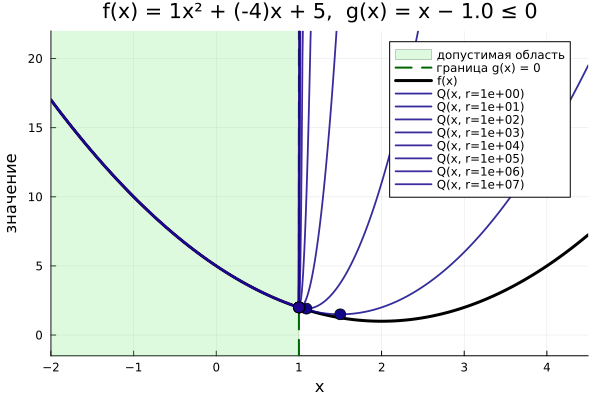


════════════════════════════════════════════════════════════════════════════════════════════════════════
  Целевая функция: f(x₁,x₂) = 2.0·x₁² + 1.0·x₂²
  Ограничения:     g₁(x₁) = 0.8 - x₁ ≤ 0  (x₁ ≥ 0.8)
                   g₂(x₂) = 0.5 - x₂ ≤ 0  (x₂ ≥ 0.5)
  Штраф:           r₁·[max(0,g₁)]² + r₂·[max(0,g₂)]²
────────────────────────────────────────────────────────────────────────────────────────────────────────
  r₁          r₂          x₁*                   x₂*                   Q(x*, r)        Penalty (∑ rᵢ·[max(0,gᵢ)]²)   
────────────────────────────────────────────────────────────────────────────────────────────────────────
  1.0000e+00  1.0000e+00  0.2666666734          0.2500000074          0.55166667      0.34694443                    
  1.0000e+01  1.0000e+01  0.6666666706          0.4545454594          1.29393939      0.19843892                    
  1.0000e+02  1.0000e+02  0.7843137268          0.4950495062          1.50242671      0.02705666                    
  1.0000e

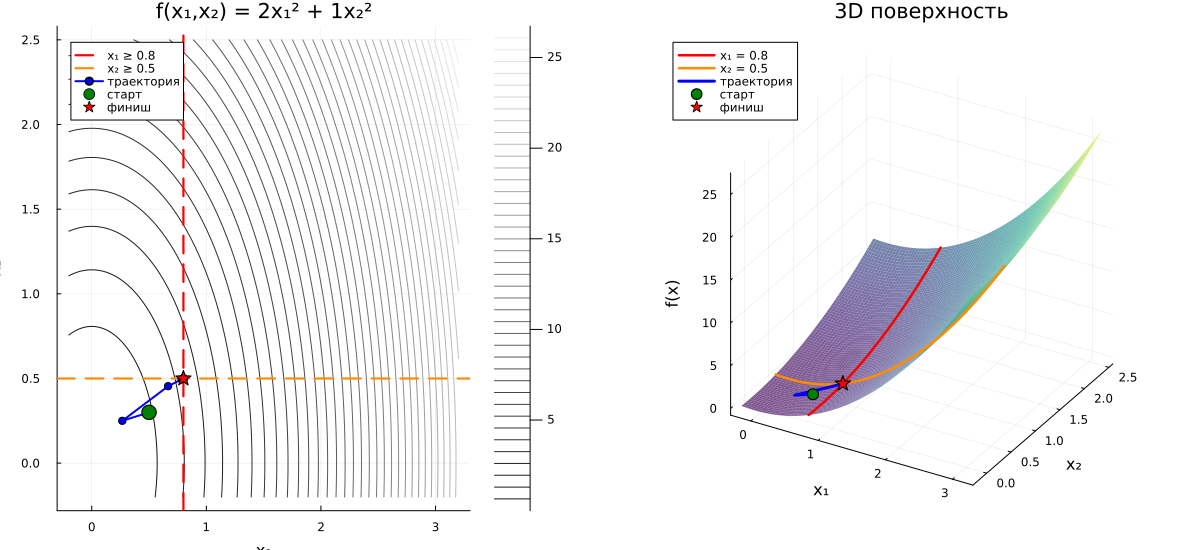

In [10]:
using LinearAlgebra
using Plots
using Printf
gr()

# ═══════════════════════════════════════════════════════════════════════
# f(x) = a·x² + b·x + c , ограничение g(x) = x - x_ub ≤ 0
# ═══════════════════════════════════════════════════════════════════════

const a1d  =  1.0          # коэффициент при x²
const b1d  = -4.0          # коэффициент при x
const c1d  =  5.0          # свободный член
const x_ub =  1.0          # верхняя граница: x ≤ x_ub

const r0_1d  = 1.0         # начальный штраф
const rk_1d  = 10.0        # множитель увеличения
const eps_1d = 1e-6        # критерий остановки

f1d(x)    = a1d*x^2 + b1d*x + c1d
g1d(x)    = x - x_ub
G_pen(t)  = max(0.0, t)^2
Q1d(x, r) = f1d(x) + r * G_pen(g1d(x))

function golden_section(φ, a, b; tol=1e-10, maxiter=1000)
    φr = (sqrt(5.0) + 1.0) / 2.0
    c  = b - (b - a) / φr
    d  = a + (b - a) / φr
    for _ in 1:maxiter
        abs(b - a) < tol && break
        φ(c) < φ(d) ? (b = d) : (a = c)
        c = b - (b - a) / φr
        d = a + (b - a) / φr
    end
    return (a + b) / 2.0
end

function run_penalty_1d()
    println("\n", "═"^80)
    println("  Целевая функция: f(x) = ", a1d, "x² + ", b1d, "x + ", c1d)
    println("  Ограничение:     g(x) = x - ", x_ub, " ≤ 0  (x ≤ ", x_ub, ")")
    println("  Штраф:           r · [max(0, g(x))]²")
    println("─"^80)

    r       = r0_1d
    x_prev  = 0.0
    records = Tuple{Float64,Float64}[]

    println(@sprintf("  %-16s  %-20s  %-14s  %-20s", "r", "x*", "Q(x*, r)", "Penalty (r·[max(0,g)]²)"))
    println("─"^80)

    for _ in 1:50
        x_new = golden_section(x -> Q1d(x, r), -10.0, 10.0)
        penalty = r * G_pen(g1d(x_new))
        println(@sprintf("  %-16.4e  %-20.10f  %-14.8f  %-20.8f",
                r, x_new, Q1d(x_new, r), penalty))
        push!(records, (r, x_new))
        abs(x_new - x_prev) ≤ eps_1d && break
        x_prev = x_new
        r      *= rk_1d
    end

    println("─"^80)
    println(@sprintf("  Найденный минимум: x* = %.8f", records[end][2]))
    println(@sprintf("  f(x*)            = %.8f", f1d(records[end][2])))
    println("═"^80)
    return records
end

records_1d = run_penalty_1d()

x_lo1, x_hi1 = -2.0, 4.5
y_lo1, y_hi1 = -1.5, 22.0
xs = range(x_lo1, x_hi1, length=800)
nrec = length(records_1d)
pal  = cgrad(:plasma, nrec + 3)

plt1 = plot(;
    background_color = :white,
    xlabel  = "x",
    ylabel  = "значение",
    title   = @sprintf("f(x) = %.0fx² + (%.0f)x + %.0f,  g(x) = x − %.1f ≤ 0",
                       a1d, b1d, c1d, x_ub),
    legend  = :topright,
    xlims   = (x_lo1, x_hi1),
    ylims   = (y_lo1, y_hi1))

plot!(plt1, Shape([x_lo1, x_ub, x_ub, x_lo1], [y_lo1, y_lo1, y_hi1, y_hi1]);
      fillcolor = :lightgreen, fillalpha = 0.30, linewidth = 0,
      label = "допустимая область")

vline!(plt1, [x_ub]; lw = 2.0, color = :darkgreen, ls = :dash,
       label = "граница g(x) = 0")

plot!(plt1, collect(xs), f1d.(xs); lw = 3.0, color = :black, label = "f(x)")

for (i, (r, x_min)) in enumerate(records_1d)
    qs = clamp.(Q1d.(xs, r), y_lo1 - 1, y_hi1 + 1)
    plot!(plt1, collect(xs), qs; lw = 1.8, color = pal[i+1], alpha = 0.85,
          label = @sprintf("Q(x, r=%.0e)", r))
    qv = Q1d(x_min, r)
    if y_lo1 ≤ qv ≤ y_hi1
        scatter!(plt1, [x_min], [qv]; ms = 6, color = pal[i+1], label = "")
    end
end

display(plt1)

# ═══════════════════════════════════════════════════════════════════════
# f(x₁,x₂) = α·x₁² + β·x₂² , ограничения: x₁ ≥ c₁ , x₂ ≥ c₂
# ═══════════════════════════════════════════════════════════════════════

const α2d   = 2.0          # коэффициент при x₁²
const β2d   = 1.0          # коэффициент при x₂²
const c1_2d = 0.8          # нижняя граница x₁
const c2_2d = 0.5          # нижняя граница x₂

const r0_2d  = 1.0         # начальные штрафы (r₁ = r₂)
const rk_2d  = 10.0        # множитель увеличения
const eps_2d = 1e-8        # критерий остановки

f2d(x)    = α2d*x[1]^2 + β2d*x[2]^2
g1_2d(x)  = c1_2d - x[1]   # ≤ 0 => x₁ ≥ c₁
g2_2d(x)  = c2_2d - x[2]   # ≤ 0 => x₂ ≥ c₂
Q2d(x, r) = f2d(x) + r[1]*G_pen(g1_2d(x)) + r[2]*G_pen(g2_2d(x))

function coordinate_descent_2d(F, x0; tol=1e-12, maxiter=800)
    x = copy(x0)
    for _ in 1:maxiter
        xp   = copy(x)
        x[1] = golden_section(t -> F([t, x[2]]), -5.0, 10.0)
        x[2] = golden_section(t -> F([x[1], t]), -5.0, 10.0)
        norm(x - xp) < tol && break
    end
    return x
end

function run_penalty_2d()
    println("\n", "═"^104)
    println("  Целевая функция: f(x₁,x₂) = ", α2d, "·x₁² + ", β2d, "·x₂²")
    println("  Ограничения:     g₁(x₁) = ", c1_2d, " - x₁ ≤ 0  (x₁ ≥ ", c1_2d, ")")
    println("                   g₂(x₂) = ", c2_2d, " - x₂ ≤ 0  (x₂ ≥ ", c2_2d, ")")
    println("  Штраф:           r₁·[max(0,g₁)]² + r₂·[max(0,g₂)]²")
    println("─"^104)

    r    = [r0_2d, r0_2d]
    x    = [0.5, 0.3]
    traj = [copy(x)]

    println(@sprintf("  %-10s  %-10s  %-20s  %-20s  %-14s  %-30s",
                     "r₁", "r₂", "x₁*", "x₂*", "Q(x*, r)", "Penalty (∑ rᵢ·[max(0,gᵢ)]²)"))
    println("─"^104)

    for i in 1:30
        x_new = coordinate_descent_2d(z -> Q2d(z, r), x)
        penalty = r[1]*G_pen(g1_2d(x_new)) + r[2]*G_pen(g2_2d(x_new))
        println(@sprintf("  %-10.4e  %-10.4e  %-20.10f  %-20.10f  %-14.8f  %-30.8f",
                r[1], r[2], x_new[1], x_new[2], Q2d(x_new, r), penalty))
        push!(traj, copy(x_new))
        norm(x_new .- x) ≤ eps_2d && break
        x = x_new
        r = r .* rk_2d
    end

    println("─"^104)
    println(@sprintf("  Найденный минимум: x* = (%.8f, %.8f)", traj[end]...))
    println(@sprintf("  f(x*)            = %.8f", f2d(traj[end])))
    println("═"^104)
    return traj
end

traj_2d = run_penalty_2d()
tx1 = [p[1] for p in traj_2d]
tx2 = [p[2] for p in traj_2d]
tfv = [f2d(p) for p in traj_2d]

x1r = range(-0.2, 3.2, length=200)
x2r = range(-0.2, 2.5, length=200)
Zc  = [f2d([x1, x2]) for x2 in x2r, x1 in x1r]

plt2a = contour(x1r, x2r, Zc;
    levels           = 40,
    color            = :grays,
    fill             = false,
    title            = @sprintf("f(x₁,x₂) = %.0fx₁² + %.0fx₂²", α2d, β2d),
    xlabel           = "x₁",
    ylabel           = "x₂",
    background_color = :white)

vline!(plt2a, [c1_2d]; lw = 2.2, color = :red, ls = :dash,
       label = @sprintf("x₁ ≥ %.1f", c1_2d))
hline!(plt2a, [c2_2d]; lw = 2.2, color = :darkorange, ls = :dash,
       label = @sprintf("x₂ ≥ %.1f", c2_2d))

plot!(plt2a, tx1, tx2; color = :blue, lw = 2,
      marker = :circle, markersize = 4, label = "траектория")
scatter!(plt2a, [tx1[1]],   [tx2[1]];
         color = :green, markersize = 8, marker = :circle, label = "старт")
scatter!(plt2a, [tx1[end]], [tx2[end]];
         color = :red, markersize = 8, marker = :star5, label = "финиш")

x1g = range(-0.2, 3.2, length=80)
x2g = range(-0.2, 2.5, length=80)
Z3  = [f2d([x1, x2]) for x2 in x2g, x1 in x1g]

plt2b = surface(x1g, x2g, Z3;
    color    = :viridis,
    alpha    = 0.7,
    colorbar = false,
    title    = "3D поверхность",
    xlabel   = "x₁",
    ylabel   = "x₂",
    zlabel   = "f(x)",
    background_color = :white)

x2_cstr = range(minimum(x2g), maximum(x2g), length=200)
z1_cstr = [f2d([c1_2d, x2]) for x2 in x2_cstr]
plot!(plt2b, fill(c1_2d, length(x2_cstr)), collect(x2_cstr), z1_cstr;
      lw = 2.5, color = :red, label = "x₁ = 0.8")

x1_cstr = range(minimum(x1g), maximum(x1g), length=200)
z2_cstr = [f2d([x1, c2_2d]) for x1 in x1_cstr]
plot!(plt2b, collect(x1_cstr), fill(c2_2d, length(x1_cstr)), z2_cstr;
      lw = 2.5, color = :darkorange, label = "x₂ = 0.5")

plot!(plt2b, tx1, tx2, tfv; color = :blue, lw = 3, label = "траектория")
scatter!(plt2b, [tx1[1]],   [tx2[1]],   [tfv[1]];
         color = :green, markersize = 6, label = "старт")
scatter!(plt2b, [tx1[end]], [tx2[end]], [tfv[end]];
         color = :red, markersize = 8, marker = :star5, label = "финиш")

display(plot(plt2a, plt2b;
             layout           = (1, 2),
             size             = (1200, 550),
             background_color = :white))